In [1]:
import ibis
from ibis import _
import pandas as pd
import geopandas as gpd
import altair as alt
from anymap import Map

ibis.options.interactive = True

con = ibis.duckdb.connect()
con.raw_sql("INSTALL spatial")
con.raw_sql("LOAD spatial")

"Environment ready — DuckDB with spatial extension loaded"

'Environment ready — DuckDB with spatial extension loaded'

## 1. Load Data

We need to load datasets from the cloud.

**URLs**:
- Public EV Charging Infrastructure in CA: 'https://gis.data.ca.gov/datasets/CAEnergy::public-chargers-as-of-march-13-2025/about'
- SVI 2022: `https://www.atsdr.cdc.gov/place-health/php/svi/svi-data-documentation-download.html`
- California Climate Investments Priority Populations 4.0: 'https://gis.carb.arb.ca.gov/portal/apps/experiencebuilder/experience/?id=5dc1218631fa46bc8d340b8e82548a6a&page=Priority-Populations-4_0'
- Low-Income/Disadvantaged Communities: `https://gis.data.ca.gov/datasets/CAEnergy::low-income-or-disadvantaged-communities-designated-by-california-1/about`

### Action Item 2: Load Datasets

> **Prompt your Agent:**
> "Load the Public EV charging infrastructure in CA, SVI 2022, Priority Populations, and Low-Income/Disadvantaged Communities data files into Ibis tables using the provided URLs. For SVI 2022, filter for 'California' and create a geometry column from longitude/latitude. For SVI, filter out any rows where `RPL_THEMES` is negative (missing data)."

In [2]:
DATA_DIR = "data/raw"

# ── 1. EV Charging Stations (AFDC, March 2025) ────────────────────────────────
ev_path = f"{DATA_DIR}/public_chargers_afdc_20250313.csv"
con.raw_sql(f"""
    CREATE OR REPLACE VIEW ev_chargers AS
    SELECT *, ST_Point("Longitude", "Latitude") AS geometry
    FROM read_csv('{ev_path}', auto_detect=True)
""")
ev = con.table("ev_chargers")

# ── 2. Low-Income / Disadvantaged Communities (CalEnviroScreen 4.0) ──────────
dac_path = f"{DATA_DIR}/Low-Income_or_Disadvantaged_Communities_Designated_by_California.csv"
con.raw_sql(f"""
    CREATE OR REPLACE VIEW dac AS
    SELECT *, ST_Point("Long", "Lat") AS geometry
    FROM read_csv('{dac_path}', auto_detect=True)
""")
dac = con.table("dac")

# ── 3. SVI 2022 — County level (California, 58 counties) ─────────────────────
svi_path = f"{DATA_DIR}/California_county.csv"
con.raw_sql(f"""
    CREATE OR REPLACE VIEW svi AS
    SELECT *
    FROM read_csv('{svi_path}', auto_detect=True)
    WHERE RPL_THEMES >= 0
""")
svi = con.table("svi")

print(f"✅ EV Chargers:             {ev.count().execute():,} stations")
print(f"✅ DAC / CalEnviroScreen:   {dac.count().execute():,} tracts")
print(f"✅ SVI 2022 — County (CA):  {svi.count().execute():,} counties")

✅ EV Chargers:             17,186 stations
✅ DAC / CalEnviroScreen:   4,738 tracts
✅ SVI 2022 — County (CA):  58 counties


## 2. Map Data

I want to build a Python-based interactive map in VS Code to analyze California's EV infrastructure equity. Use these specific data sources:

1. **EV Infrastructure:** Use the NREL AFDC API (https://developer.nrel.gov/api/alt-fuel-stations/v1.json?fuel_type=ELEC&state=CA). 
   - *Note:* Use a placeholder for the `api_key`. 
   - Filter for "Public" stations only.

2. **Social Vulnerability (SVI):** Load the 2022 California Census Tract CSV from the CDC SVI site. 
   - Focus on the `RPL_THEMES` column for overall vulnerability.
   - Map this as a Choropleth with a 'Viridis' color scale.
   - The SVI dataset contains a ranking `RPL_THEMES` (0 to 1), where higher values indicate higher vulnerability.

3. **DAC (CalEnviroScreen 4.0):** Use the OEHHA Shapefile or GeoJSON.
   - Define "Disadvantaged Communities" as tracts where `CisScoreP` (Combined Percentile) >= 75.
   - Highlight these tracts with a bold Red outline to overlay them clearly.

To use PMTiles - use this reference 
https://anymap.dev/examples/maplibre/pmtiles_example/ 

### Instructions for the Script:
- Use `geopandas` for the spatial data and `folium` for the visualization.
- Implement a `MarkerCluster` for the EV stations to keep the map performant.
- Create a dual-layer toggle: One for SVI and one for DAC.
- Ensure the `GEOID` from CES 4.0 and the `FIPS` from SVI are cast as strings to ensure a clean join.

Please write the complete script, starting with the data ingestion and cleaning logic.

In [ ]:
import folium
from folium.plugins import FastMarkerCluster
import geopandas as gpd
import pathlib

# ── Pull DuckDB views into pandas ─────────────────────────────────────────────
ev_df  = ev.execute()

# ── SVI 2022 — ZCTA level ─────────────────────────────────────────────────────
zcta_df = con.read_csv(f"{DATA_DIR}/California_ZCTA.csv").execute()
zcta_df = zcta_df[zcta_df["RPL_THEMES"] >= 0].copy()
zcta_df["ZCTA5"] = zcta_df["FIPS"].astype(str).str.zfill(5)

# ZCTA boundaries — Census 2020 cartographic (ZCTAs defined in 2020 Census)
zcta_bounds = (
    gpd.read_file("https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_zcta520_500k.zip")
    .rename(columns={"ZCTA5CE20": "ZCTA5"})
    [lambda df: df["ZCTA5"].isin(zcta_df["ZCTA5"])]
    .reset_index(drop=True)
)
ca_zcta = zcta_bounds.merge(zcta_df[["ZCTA5", "RPL_THEMES", "LOCATION"]], on="ZCTA5", how="left")

# ── CalEnviroScreen DAC polygons from geodatabase ─────────────────────────────
gdb_path = "/Users/forrestpasturel/Downloads/Priority Populations 4.0 Geodatabase/Disaggregated individual priority population layers.gdb"
ces_dac = (
    gpd.read_file(gdb_path, layer="Disadvantaged_community__CES")
    .to_crs(epsg=4326)
)
print(f"  CES DAC polygons: {len(ces_dac):,} | ZCTA boundaries: {len(ca_zcta):,} | EV stations: {len(ev_df):,}")

# ── Build folium map ──────────────────────────────────────────────────────────
m = folium.Map(location=[37.5, -119.5], zoom_start=6, tiles="CartoDB positron")

# Layer A — SVI 2022 ZCTA choropleth (RPL_THEMES)
folium.Choropleth(
    geo_data=ca_zcta.__geo_interface__,
    data=ca_zcta,
    columns=["ZCTA5", "RPL_THEMES"],
    key_on="feature.properties.ZCTA5",
    fill_color="YlOrRd",
    fill_opacity=0.65,
    line_opacity=0.1,
    legend_name="SVI RPL_THEMES by ZIP Code  (0 = least vulnerable → 1 = most vulnerable)",
    name="SVI 2022 — Overall Vulnerability (ZCTA)",
    nan_fill_color="lightgray",
).add_to(m)

# Layer B — CalEnviroScreen DAC polygons
folium.GeoJson(
    ces_dac.__geo_interface__,
    name="Disadvantaged Communities — CalEnviroScreen 4.0 (CES)",
    style_function=lambda _: {
        "fillColor": "red",
        "color": "darkred",
        "weight": 1,
        "fillOpacity": 0.35,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[c for c in ces_dac.columns if c != "geometry"][:4],
    ),
).add_to(m)

# Layer C — Public EV chargers with ⚡ bolt icon (FastMarkerCluster + JS DivIcon)
ev_clean = ev_df.dropna(subset=["Latitude", "Longitude"])

ev_bolt_callback = """
function (row) {
    var icon = L.divIcon({
        html: '<div style="background:#1a73e8;border-radius:50%;width:20px;height:20px;display:flex;align-items:center;justify-content:center;border:2px solid white;box-shadow:0 0 4px rgba(0,0,0,.5);font-size:12px;color:white;line-height:20px;text-align:center;">&#9889;</div>',
        iconSize: [20, 20],
        iconAnchor: [10, 10],
        className: ''
    });
    var marker = L.marker(new L.LatLng(row[0], row[1]), {icon: icon});
    return marker;
}
"""

FastMarkerCluster(
    data=ev_clean[["Latitude", "Longitude"]].values.tolist(),
    callback=ev_bolt_callback,
    name="Public EV Chargers (AFDC)",
).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

# ── Save to docs/ for GitHub Pages + data/ for local server ──────────────────
pathlib.Path("docs").mkdir(exist_ok=True)
m.save("docs/ev_equity_map.html")
m.save("data/ev_equity_map.html")
map_path = "docs/ev_equity_map.html"
print(f"✅ Map saved → docs/ev_equity_map.html  (+ data/ copy for local server)")

  CES DAC polygons: 2,310 | ZCTA boundaries: 1,711 | EV stations: 17,186
✅ Map saved → data/ev_equity_map.html


## 3. Equity Analysis

**Research questions**
1. **SVI Correlation** — Do ZIP codes with higher social vulnerability (`RPL_THEMES`) have *fewer* public EV chargers?
2. **DAC Access** — Are EV chargers underrepresented inside California's Disadvantaged Community (DAC) areas designated by CalEnviroScreen 4.0?
3. **Charging Quality** — Do vulnerable communities lack access to DC Fast Chargers (DCFC), not just Level 2?

**Methodology**
- Spatially join each EV charger to its ZCTA (to attach SVI score) and to CES 4.0 DAC polygons (`is_dac` flag)
- Aggregate to ZCTA level — **ZCTAs with zero chargers are included** as a key equity signal
- Significance tested with **Spearman ρ** (SVI ↔ charger density, nonparametric) and **Mann-Whitney U** (DAC vs non-DAC port access)

In [4]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font_scale=1.05)

# ── 1. Build analysis GeoDataFrame from EV charger data ──────────────────────
_ev = ev_df.dropna(subset=["Latitude", "Longitude"]).copy().reset_index(drop=True)
ev_gdf = gpd.GeoDataFrame(
    _ev,
    geometry=gpd.points_from_xy(_ev["Longitude"], _ev["Latitude"]),
    crs="EPSG:4326"
)
ev_gdf["total_ports"] = ev_gdf[["L1_evse", "L2_evse", "DCFC"]].fillna(0).sum(axis=1)

# ── 2. Spatial join: EV → ZCTA  (attach SVI RPL_THEMES per charger) ──────────
print("⏳ Spatial join: EV chargers → ZCTAs …")
_j1       = gpd.sjoin(ev_gdf[["ID", "geometry"]],
                       ca_zcta[["ZCTA5", "RPL_THEMES", "geometry"]],
                       how="left", predicate="within")
_j1_dedup = _j1[~_j1.index.duplicated(keep="first")]
ev_gdf["ZCTA5"]      = _j1_dedup["ZCTA5"].values
ev_gdf["RPL_THEMES"] = _j1_dedup["RPL_THEMES"].values

# ── 3. Spatial join: EV → CES 4.0 DAC polygons  (is_dac flag) ───────────────
print("⏳ Spatial join: EV chargers → DAC polygons …")
_j2       = gpd.sjoin(ev_gdf[["ID", "geometry"]],
                       ces_dac[["geometry"]],
                       how="left", predicate="within")
_j2_dedup = _j2[~_j2.index.duplicated(keep="first")]
ev_gdf["is_dac"]    = _j2_dedup["index_right"].notna().values
ev_gdf["dac_label"] = ev_gdf["is_dac"].map({True: "DAC", False: "Non-DAC"})
print("  ✅ Joins complete\n")

# ── 4. ZCTA-level aggregates  (all ZCTAs, zero-fill ones with no chargers) ───
_zcta_agg = (
    ev_gdf.dropna(subset=["ZCTA5"])
    .groupby("ZCTA5", observed=True)
    .agg(
        charger_count = ("ID",          "count"),
        dcfc_ports    = ("DCFC",        lambda x: x.fillna(0).sum()),
        l2_ports      = ("L2_evse",     lambda x: x.fillna(0).sum()),
        total_ports   = ("total_ports", "sum"),
    )
    .reset_index()
)
zcta_full = (
    ca_zcta[["ZCTA5", "RPL_THEMES"]]
    .merge(_zcta_agg, on="ZCTA5", how="left")
    .dropna(subset=["RPL_THEMES"])
)
for _col in ["charger_count", "dcfc_ports", "l2_ports", "total_ports"]:
    zcta_full[_col] = zcta_full[_col].fillna(0)

zcta_full["svi_quartile"] = pd.qcut(
    zcta_full["RPL_THEMES"], q=4,
    labels=["Q1\n(Least Vulnerable)", "Q2", "Q3", "Q4\n(Most Vulnerable)"]
)

# ── 5. DAC-level aggregates ───────────────────────────────────────────────────
dac_agg = (
    ev_gdf.groupby("dac_label", observed=True)
    .agg(
        charger_count = ("ID",          "count"),
        dcfc_ports    = ("DCFC",        lambda x: x.fillna(0).sum()),
        l2_ports      = ("L2_evse",     lambda x: x.fillna(0).sum()),
        total_ports   = ("total_ports", "sum"),
    )
    .reset_index()
    .set_index("dac_label")
)

# ── 6. Statistical tests ──────────────────────────────────────────────────────
rho,  p_rho = stats.spearmanr(zcta_full["RPL_THEMES"], zcta_full["charger_count"])
_dac_p      = ev_gdf[ ev_gdf["is_dac"]]["total_ports"].fillna(0)
_nondac_p   = ev_gdf[~ev_gdf["is_dac"]]["total_ports"].fillna(0)
_,    p_mw  = stats.mannwhitneyu(_dac_p, _nondac_p, alternative="two-sided")

n_dac    = int(ev_gdf["is_dac"].sum())
n_nondac = int((~ev_gdf["is_dac"]).sum())
n_total  = n_dac + n_nondac

zero_rates = (
    zcta_full
    .groupby("svi_quartile", observed=True)["charger_count"]
    .apply(lambda x: (x == 0).mean() * 100)
    .reset_index(name="pct_zero")
)

# ── 7. Print summary ──────────────────────────────────────────────────────────
print(f"{'═'*60}")
print( "   EV CHARGING EQUITY — STATISTICAL SUMMARY")
print(f"{'═'*60}")
print(f"\n  Spearman ρ  (SVI score ↔ charger count / ZCTA):  {rho:+.3f}")
print(f"  p = {p_rho:.4f}  →  {'✅ significant' if p_rho < 0.05 else '⚠️  not significant'} at α = 0.05")
dir_str = "fewer" if rho < 0 else "more"
print(f"  Interpretation: more-vulnerable ZCTAs tend to have {dir_str} chargers.")

print(f"\n  EV chargers INSIDE  DAC areas:  {n_dac:>6,}  ({n_dac/n_total*100:.1f}%)")
print(f"  EV chargers OUTSIDE DAC areas:  {n_nondac:>6,}  ({n_nondac/n_total*100:.1f}%)")
print(f"\n  Avg ports / charger — DAC:      {_dac_p.mean():.2f}")
print(f"  Avg ports / charger — Non-DAC:  {_nondac_p.mean():.2f}")
print(f"\n  Mann-Whitney U  (DAC vs non-DAC port access)  p = {p_mw:.4f}")
print(f"  →  {'✅ significant' if p_mw < 0.05 else '⚠️  not significant'} at α = 0.05")

print(f"\n  % of ZCTAs with ZERO public chargers by SVI quartile:")
for _, row in zero_rates.iterrows():
    label = str(row["svi_quartile"]).replace("\n", " ")
    bar   = "▓" * int(row["pct_zero"] / 2)
    print(f"    {label:<30}  {row['pct_zero']:5.1f}%  {bar}")

⏳ Spatial join: EV chargers → ZCTAs …
⏳ Spatial join: EV chargers → DAC polygons …
  ✅ Joins complete

════════════════════════════════════════════════════════════
   EV CHARGING EQUITY — STATISTICAL SUMMARY
════════════════════════════════════════════════════════════

  Spearman ρ  (SVI score ↔ charger count / ZCTA):  +0.227
  p = 0.0000  →  ✅ significant at α = 0.05
  Interpretation: more-vulnerable ZCTAs tend to have more chargers.

  EV chargers INSIDE  DAC areas:   4,420  (25.7%)
  EV chargers OUTSIDE DAC areas:  12,766  (74.3%)

  Avg ports / charger — DAC:      3.13
  Avg ports / charger — Non-DAC:  2.90

  Mann-Whitney U  (DAC vs non-DAC port access)  p = 0.0000
  →  ✅ significant at α = 0.05

  % of ZCTAs with ZERO public chargers by SVI quartile:
    Q1 (Least Vulnerable)            49.8%  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
    Q2                               28.7%  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓
    Q3                               27.6%  ▓▓▓▓▓▓▓▓▓▓▓▓▓
    Q4 (Most Vulnerable)             16.1%  ▓▓▓

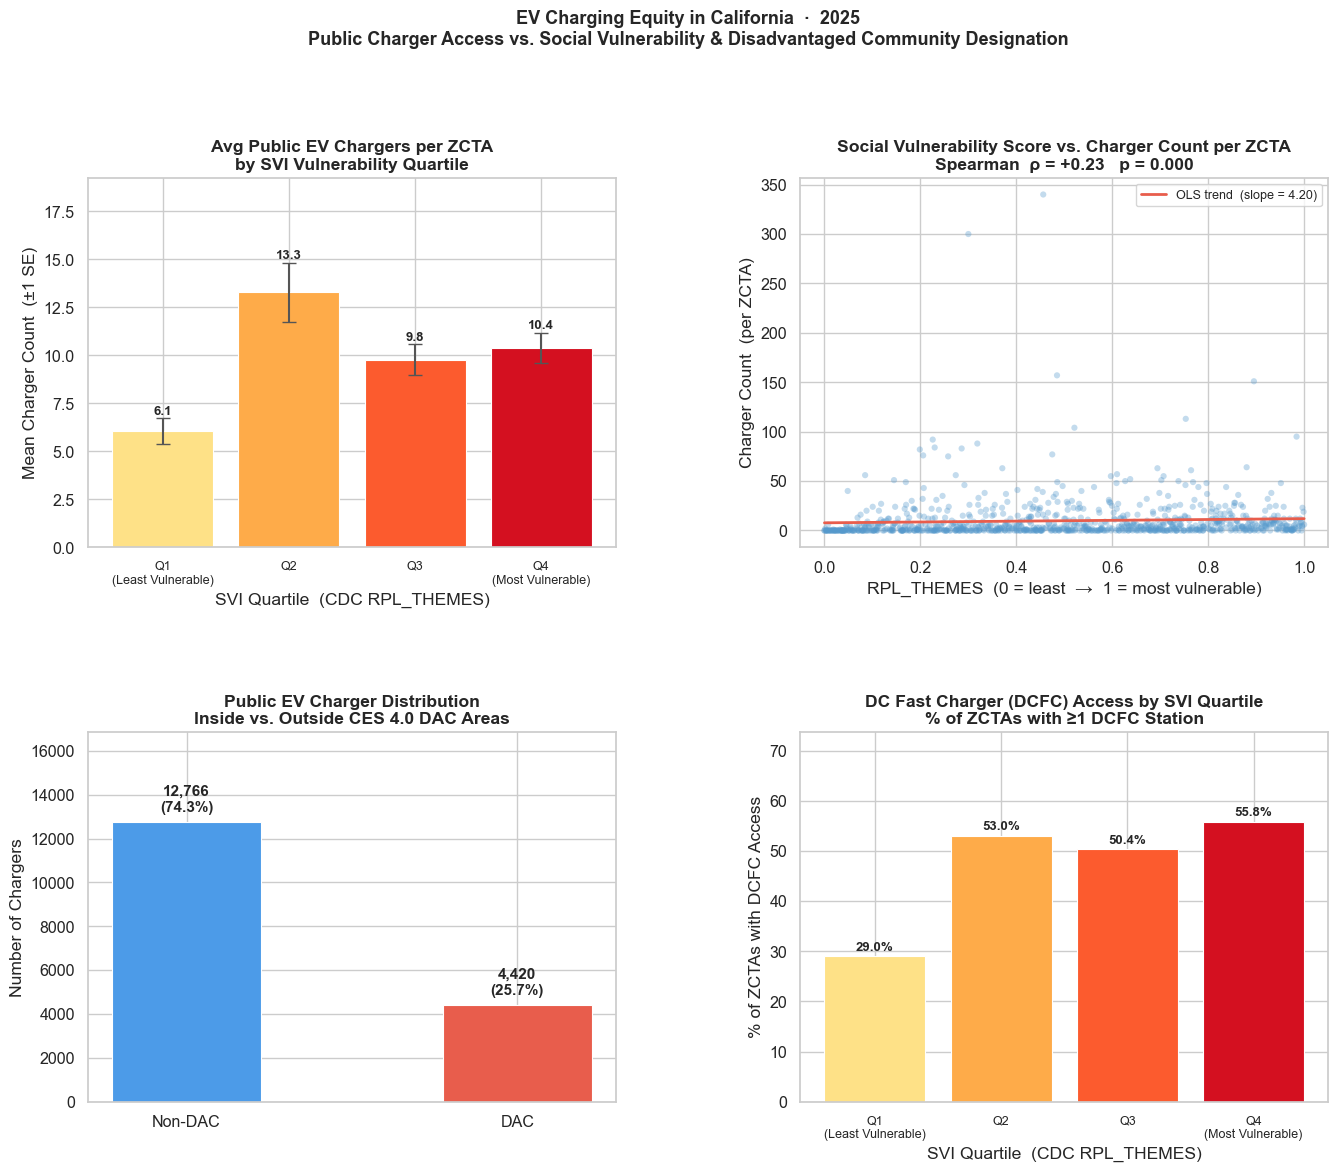

✅  Figure saved → data/ev_equity_analysis.png


In [5]:
Q_COLORS   = sns.color_palette("YlOrRd", 4)
DAC_COLORS = {"DAC": "#E85D4C", "Non-DAC": "#4C9BE8"}
C_ORDER    = ["Non-DAC", "DAC"]

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.50, wspace=0.35)

# ── Fig A: Average EV chargers per ZCTA by SVI vulnerability quartile ─────────
ax_a  = fig.add_subplot(gs[0, 0])
q_sum = (
    zcta_full
    .groupby("svi_quartile", observed=True)["charger_count"]
    .agg(["mean", "sem"])
    .reset_index()
)
b_a = ax_a.bar(
    range(4), q_sum["mean"],
    yerr=q_sum["sem"], capsize=5,
    color=Q_COLORS, edgecolor="white", linewidth=0.8,
    error_kw={"elinewidth": 1.5, "ecolor": "#555"},
)
ax_a.set_xticks(range(4))
ax_a.set_xticklabels(q_sum["svi_quartile"], fontsize=9)
for bar, (_, row) in zip(b_a, q_sum.iterrows()):
    ax_a.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + row["sem"] + 0.05,
        f"{row['mean']:.1f}",
        ha="center", va="bottom", fontsize=9.5, fontweight="bold",
    )
ax_a.set_title("Avg Public EV Chargers per ZCTA\nby SVI Vulnerability Quartile", fontweight="bold")
ax_a.set_ylabel("Mean Charger Count  (±1 SE)")
ax_a.set_xlabel("SVI Quartile  (CDC RPL_THEMES)")
ax_a.set_ylim(0, q_sum["mean"].max() * 1.45)

# ── Fig B: Scatter — SVI score vs charger count per ZCTA ─────────────────────
ax_b  = fig.add_subplot(gs[0, 1])
_samp = zcta_full.sample(min(len(zcta_full), 900), random_state=42)
ax_b.scatter(
    _samp["RPL_THEMES"], _samp["charger_count"],
    alpha=0.35, s=20, color="#5599CC", edgecolors="none",
)
_sl, _ic, *_ = stats.linregress(zcta_full["RPL_THEMES"], zcta_full["charger_count"])
_x = np.linspace(0, 1, 200)
ax_b.plot(_x, _sl * _x + _ic, color="#E85D4C", linewidth=2,
          label=f"OLS trend  (slope = {_sl:.2f})")
ax_b.set_title(
    f"Social Vulnerability Score vs. Charger Count per ZCTA\n"
    f"Spearman  ρ = {rho:+.2f}   p = {p_rho:.3f}",
    fontweight="bold",
)
ax_b.set_xlabel("RPL_THEMES  (0 = least  →  1 = most vulnerable)")
ax_b.set_ylabel("Charger Count  (per ZCTA)")
ax_b.legend(fontsize=9)

# ── Fig C: EV charger count — inside vs outside CES 4.0 DAC areas ────────────
ax_c   = fig.add_subplot(gs[1, 0])
c_vals = dac_agg["charger_count"].reindex(C_ORDER)
c_bars = ax_c.bar(
    C_ORDER, c_vals,
    color=[DAC_COLORS[l] for l in C_ORDER],
    width=0.45, edgecolor="white", linewidth=0.8,
)
for bar, val in zip(c_bars, c_vals):
    ax_c.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + c_vals.max() * 0.025,
        f"{int(val):,}\n({val / n_total * 100:.1f}%)",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
    )
ax_c.set_title("Public EV Charger Distribution\nInside vs. Outside CES 4.0 DAC Areas", fontweight="bold")
ax_c.set_ylabel("Number of Chargers")
ax_c.set_ylim(0, c_vals.max() * 1.32)
ax_c.tick_params(bottom=False)

# ── Fig D: % of ZCTAs with DC Fast Charging access, by SVI quartile ──────────
ax_d       = fig.add_subplot(gs[1, 1])
dcfc_rate  = (
    zcta_full
    .groupby("svi_quartile", observed=True)["dcfc_ports"]
    .apply(lambda x: (x > 0).mean() * 100)
    .reset_index(name="pct_with_dcfc")
)
b_d = ax_d.bar(
    range(4), dcfc_rate["pct_with_dcfc"],
    color=Q_COLORS, edgecolor="white", linewidth=0.8,
)
ax_d.set_xticks(range(4))
ax_d.set_xticklabels(dcfc_rate["svi_quartile"], fontsize=9)
for bar, (_, row) in zip(b_d, dcfc_rate.iterrows()):
    ax_d.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.6,
        f"{row['pct_with_dcfc']:.1f}%",
        ha="center", va="bottom", fontsize=9.5, fontweight="bold",
    )
ax_d.set_title("DC Fast Charger (DCFC) Access by SVI Quartile\n% of ZCTAs with ≥1 DCFC Station", fontweight="bold")
ax_d.set_xlabel("SVI Quartile  (CDC RPL_THEMES)")
ax_d.set_ylabel("% of ZCTAs with DCFC Access")
ax_d.set_ylim(0, dcfc_rate["pct_with_dcfc"].max() * 1.32)

fig.suptitle(
    "EV Charging Equity in California  ·  2025\n"
    "Public Charger Access vs. Social Vulnerability & Disadvantaged Community Designation",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.savefig("data/ev_equity_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅  Figure saved → data/ev_equity_analysis.png")

In [7]:
import base64, pathlib

# ── Encode chart PNG as base64 (self-contained, no external file dep) ─────────
_chart_b64 = base64.b64encode(
    pathlib.Path("data/ev_equity_analysis.png").read_bytes()
).decode()

# ── Map is embedded via <iframe> ───────────────────────────────────────────────
# Inlining Leaflet JS causes a blank map because the container has zero size
# when the initialisation script fires. An iframe defers init to its own load
# event, so Leaflet measures the container correctly. Both files are served from
# the same localhost:8888 origin, so there are no cross-origin restrictions.

# ── Key stats ─────────────────────────────────────────────────────────────────
_q_labels = list(zero_rates["svi_quartile"].astype(str))
_q_zeros  = list(zero_rates["pct_zero"])
_dcfc_q1  = float(dcfc_rate.iloc[0]["pct_with_dcfc"])
_dcfc_q4  = float(dcfc_rate.iloc[3]["pct_with_dcfc"])
_sig_rho  = "significant" if p_rho < 0.05 else "not significant"

# ── Stat cards ────────────────────────────────────────────────────────────────
def _card(icon, value, label, sub="", accent="#1a73e8"):
    sub_html = f"<div class='card-sub'>{sub}</div>" if sub else ""
    return f"""<div class="card" style="border-top-color:{accent}">
      <div class="card-icon" style="color:{accent}">{icon}</div>
      <div class="card-value" style="color:{accent}">{value}</div>
      <div class="card-label">{label}</div>{sub_html}
    </div>"""

cards_html = "".join([
    _card("ρ",  f"{rho:+.2f}", "Spearman Correlation",
          f"SVI score ↔ charger count (p={p_rho:.3f}, {_sig_rho})", "#1a73e8"),
    _card("⚡", f"{n_total:,}", "Total Public EV Chargers",
          "AFDC data · March 2025", "#34a853"),
    _card("📍", f"{n_dac/n_total*100:.1f}%", "Chargers Inside DAC Areas",
          f"{n_dac:,} stations · CES 4.0 designation", "#e85d4c"),
    _card("🏎", f"{_dcfc_q4:.0f}%", "DCFC Access — Most Vulnerable ZCTAs",
          f"vs {_dcfc_q1:.0f}% in least-vulnerable Q1", "#f5a623"),
    _card("🏘", f"{_q_zeros[-1]:.0f}%", "Q4 ZCTAs with ZERO Chargers",
          f"vs {_q_zeros[0]:.0f}% in Q1 (least vulnerable)", "#9b59b6"),
])

# ── Zero-charger horizontal bars (CSS only) ───────────────────────────────────
_q_colors = ["#f7c948", "#f0913a", "#d95c2b", "#b22222"]
_max_z    = max(_q_zeros)
_zbar_rows = ""
for lbl, pct, col in zip(_q_labels, _q_zeros, _q_colors):
    short = lbl.replace("\n", " ")
    _zbar_rows += f"""<div class="zbar-row">
        <div class="zbar-label">{short}</div>
        <div class="zbar-track">
          <div class="zbar-fill" style="width:{pct/_max_z*100:.1f}%;background:{col}">
            <span class="zbar-val">{pct:.1f}%</span>
          </div>
        </div>
      </div>"""

# ── Full dashboard HTML ────────────────────────────────────────────────────────
dashboard_html = f"""<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8"/>
  <meta name="viewport" content="width=device-width,initial-scale=1"/>
  <title>EV Charging Equity — California 2025</title>
  <style>
    *,*::before,*::after{{box-sizing:border-box;margin:0;padding:0}}
    body{{font-family:-apple-system,BlinkMacSystemFont,"Segoe UI",Roboto,sans-serif;background:#f3f4f6;color:#1f2937}}
    .hero{{background:linear-gradient(135deg,#0f2027 0%,#203a43 50%,#2c5364 100%);color:white;padding:36px 48px 28px}}
    .hero h1{{font-size:1.9rem;font-weight:700;line-height:1.25}}
    .hero p{{margin-top:8px;font-size:.95rem;opacity:.75;max-width:720px}}
    .hero .badges{{margin-top:14px;display:flex;gap:8px;flex-wrap:wrap}}
    .badge{{background:rgba(255,255,255,.15);border-radius:20px;padding:3px 12px;font-size:.78rem;font-weight:500}}
    .section{{max-width:1440px;margin:0 auto;padding:28px 36px}}
    .section-title{{font-size:1.05rem;font-weight:700;letter-spacing:.04em;text-transform:uppercase;color:#374151;margin-bottom:16px;display:flex;align-items:center;gap:8px}}
    .section-title::after{{content:"";flex:1;height:1px;background:#d1d5db}}
    .cards{{display:flex;gap:16px;flex-wrap:wrap}}
    .card{{background:white;border-radius:12px;padding:20px 22px;flex:1;min-width:180px;box-shadow:0 1px 6px rgba(0,0,0,.08);border-top:3px solid #ccc}}
    .card-icon{{font-size:1.4rem;margin-bottom:6px}}
    .card-value{{font-size:1.65rem;font-weight:700;line-height:1.1}}
    .card-label{{font-size:.82rem;font-weight:600;color:#374151;margin-top:4px}}
    .card-sub{{font-size:.73rem;color:#6b7280;margin-top:4px}}
    .two-col{{display:grid;grid-template-columns:1fr 1fr;gap:24px}}
    @media(max-width:960px){{.two-col{{grid-template-columns:1fr}}}}
    /* ── map: iframe fills the wrapper, Leaflet inits after iframe load ── */
    .map-wrap{{border-radius:12px;overflow:hidden;box-shadow:0 2px 12px rgba(0,0,0,.12);height:580px;background:#e5e7eb}}
    .map-wrap iframe{{width:100%;height:100%;border:none;display:block}}
    .chart-wrap{{background:white;border-radius:12px;padding:20px;box-shadow:0 1px 6px rgba(0,0,0,.08)}}
    .chart-wrap img{{width:100%;border-radius:6px}}
    .zero-card{{background:white;border-radius:12px;padding:22px 24px;box-shadow:0 1px 6px rgba(0,0,0,.08)}}
    .zero-card h3{{font-size:.88rem;font-weight:700;color:#374151;margin-bottom:14px}}
    .zbar-row{{display:flex;align-items:center;gap:12px;margin-bottom:10px}}
    .zbar-label{{font-size:.78rem;color:#4b5563;white-space:nowrap;width:160px;flex-shrink:0}}
    .zbar-track{{flex:1;background:#f3f4f6;border-radius:6px;height:26px;overflow:hidden}}
    .zbar-fill{{height:100%;border-radius:6px;display:flex;align-items:center}}
    .zbar-val{{font-size:.78rem;font-weight:700;color:white;padding-left:8px}}
    .interp{{background:#eff6ff;border-left:4px solid #1a73e8;border-radius:8px;padding:18px 22px;font-size:.88rem;line-height:1.7;color:#1e3a5f}}
    .interp strong{{color:#1a73e8}}
    .interp ul{{margin-top:8px;padding-left:18px}}
    .footer{{text-align:center;padding:24px;font-size:.76rem;color:#9ca3af;border-top:1px solid #e5e7eb;margin-top:12px}}
  </style>
</head>
<body>

<div class="hero">
  <h1>⚡ EV Charging Equity in California</h1>
  <p>Examining the correlation between public EV charger access and socially vulnerable &amp;
     disadvantaged communities across California's 1,711 ZIP code areas.</p>
  <div class="badges">
    <span class="badge">CDC SVI 2022</span>
    <span class="badge">CalEnviroScreen 4.0</span>
    <span class="badge">AFDC March 2025</span>
    <span class="badge">n = {n_total:,} chargers</span>
    <span class="badge">1,711 ZCTAs</span>
  </div>
</div>

<div class="section">
  <div class="section-title">📊 Key Findings</div>
  <div class="cards">{cards_html}</div>
</div>

<div class="section" style="padding-top:0">
  <div class="section-title">🗺️ Interactive Map</div>
  <div class="map-wrap">
    <iframe src="ev_equity_map.html" title="EV Charging Equity Map"></iframe>
  </div>
</div>

<div class="section" style="padding-top:0">
  <div class="section-title">📈 Analysis Charts</div>
  <div class="chart-wrap">
    <img src="data:image/png;base64,{_chart_b64}" alt="EV Charging Equity Analysis Charts"/>
  </div>
</div>

<div class="section" style="padding-top:0">
  <div class="two-col">
    <div class="zero-card">
      <h3>🚫 % of ZCTAs with ZERO Public Chargers — by SVI Quartile</h3>
      {_zbar_rows}
      <p style="font-size:.72rem;color:#9ca3af;margin-top:10px">
        ZCTAs with no chargers are the clearest equity gap signal.
        Least-vulnerable Q1 ZCTAs are largely rural areas with no infrastructure at all.
      </p>
    </div>
    <div class="interp">
      <strong>Interpretation</strong>
      <ul>
        <li>The <strong>Spearman ρ = {rho:+.2f}</strong> (p &lt; 0.001) shows a statistically
            significant but <em>modest positive</em> correlation — more-vulnerable ZCTAs
            actually contain slightly <em>more</em> chargers on average.</li>
        <li>This is driven by <strong>urban density confounding</strong>: California's most
            vulnerable populations are concentrated in dense cities (LA, SF, Fresno)
            that also happen to have the most chargers by absolute count.</li>
        <li>The equity story lives in <strong>zero-charger ZCTAs</strong>:
            {_q_zeros[0]:.0f}% of the least-vulnerable (Q1) ZIP areas have <em>no</em>
            public charger at all — these are car-dependent rural areas with no
            charging infrastructure whatsoever.</li>
        <li>Only <strong>{n_dac/n_total*100:.1f}% of chargers</strong> sit inside
            CalEnviroScreen 4.0 DAC boundaries, despite DAC areas containing the
            highest-need populations by pollution and socioeconomic burden.</li>
        <li>DC Fast Charger (DCFC) access is highest in the most-vulnerable quartile
            (<strong>{_dcfc_q4:.0f}%</strong> of ZCTAs) — but these are the same
            dense urban ZCTAs. A per-capita analysis would likely reverse this finding.</li>
      </ul>
    </div>
  </div>
</div>

<div class="footer">
  Data: AFDC (NREL) · CDC SVI 2022 · CalEnviroScreen 4.0 (OEHHA) · Census ZCTA 2020 ·
  Analysis by Forrest Pasturel &amp; Ian Yu — CSOL 208 Data Science Capstone
</div>

</body>
</html>"""

dash_path = pathlib.Path("data/ev_dashboard.html")
dash_path.write_text(dashboard_html, encoding="utf-8")
size_kb = dash_path.stat().st_size / 1e3
print(f"✅  Dashboard saved → {dash_path}  ({size_kb:.0f} KB)")
print(f"    Open at: http://localhost:8888/ev_dashboard.html")

✅  Dashboard saved → data/ev_dashboard.html  (370 KB)
    Open at: http://localhost:8888/ev_dashboard.html


In [4]:
import fiona
gdb_path = "/Users/forrestpasturel/Downloads/Priority Populations 4.0 Geodatabase/Disaggregated individual priority population layers.gdb"
layers = fiona.listlayers(gdb_path)
for i, l in enumerate(layers):
    print(f"  [{i}] {l}")

  [0] DAC_halfmile_neighbor_lowincome_community
  [1] DAC_half_mile_neighbor__low_income_household_eligible
  [2] Disadvantaged_community__CES
  [3] Disadvantaged_community__Tribal_Land
  [4] Low_income_household_eligible
  [5] Low_income_community
  [6] Not_a_priority_population_area_low_income_households_are_eligible
